ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

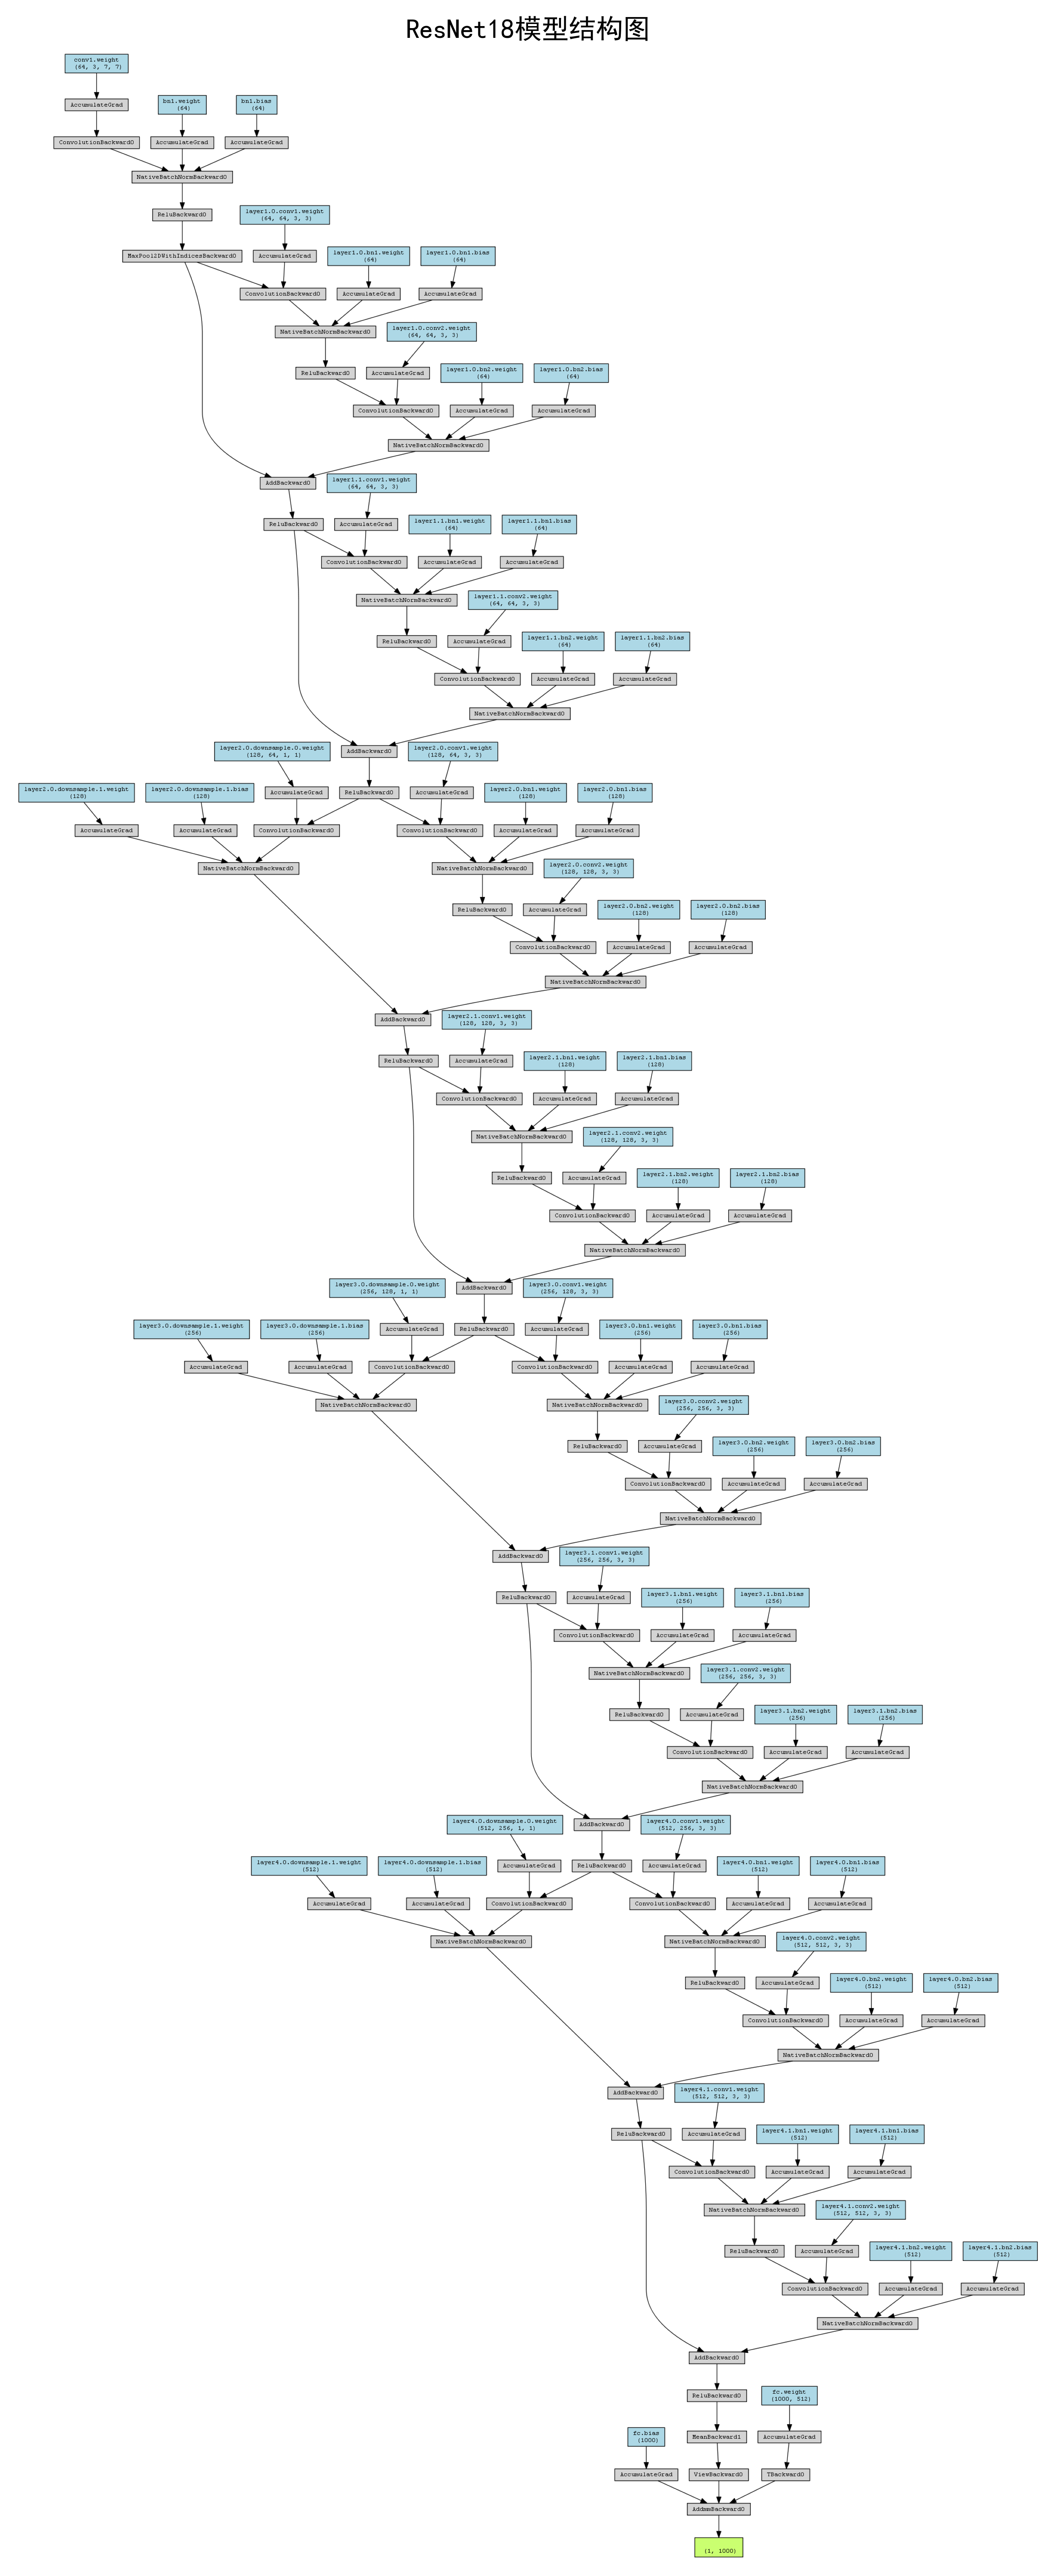

ResNet18模型的详细参数信息:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14

In [1]:
import torchvision.models as models   # 导入torchvision中的模型库

# 加载预训练的ResNet18模型，不指定pretrained参数时默认加载未训练模型
resnet18 = models.resnet18()

# 打印ResNet18模型的整体网络结构
print(resnet18)

# 计算ResNet18模型的参数总数，并友好地格式化输出（千位分隔符）
total_params = sum(p.numel() for p in resnet18.parameters())
print(f"resnet18模型的总参数量: {total_params:,}")

# 导入后续可视化和辅助功能所需的库
import torch
from torchviz import make_dot                        # 用于生成模型的计算图
from torch.autograd import Variable                  # 用于创建自动求导变量
import matplotlib.pyplot as plt                      # 用于图片显示
import io                                            # （可选，未使用但可用于内存流）
from PIL import Image                                # 用于读取PNG图片
from torchsummary import summary                     # 用于详细打印模型信息
import numpy as np                                   # 用于数值处理

# 创建一个示例输入，大小为(1, 3, 224, 224)，包含batch维度。
# 3是输入通道数(彩色图像)，224x224是图片尺寸。
x = Variable(torch.randn(1, 3, 224, 224))

# 将示例输入传入ResNet18模型，获得输出张量
y = resnet18(x)

# 配置matplotlib，以支持显示中文（用于图例和标题美观）
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']  # 尝试多种常见中文字体
rcParams['axes.unicode_minus'] = False  # 防止坐标轴负号显示异常

# 使用torchviz的make_dot函数，根据模型输出和参数，生成可视化的计算图
dot = make_dot(y, params=dict(resnet18.named_parameters()))

# 设置保存格式为png，并渲染生成"resnet18_structure.png"，完成后删除中间的.dot文件
dot.format = 'png'
dot.render("resnet18_structure", cleanup=True)

# 读取保存的png图片，并在notebook中显示，用于观察网络的计算流图结构
try:
    img = Image.open("resnet18_structure.png")       # 打开刚保存的网络结构图片
    plt.figure(figsize=(15, 20), dpi=400)            # 设置显示区域大小与分辨率
    plt.imshow(np.array(img))                        # 转为numpy数组再显示
    plt.axis('off')                                  # 不显示坐标轴
    plt.title("ResNet18模型结构图")                    # 图像标题
    plt.show()
except:
    # 若图像读取失败，给出提示（可能是torchviz未安装或运行失败）
    print("无法显示图像，请检查torchviz是否正确安装")

# 使用torchsummary库，输出模型每层结构、输出尺寸与参数统计信息，更直观方便查看
print("ResNet18模型的详细参数信息:")
summary(resnet18, (3, 224, 224), device="cpu")       # 指定输入尺寸与设备


In [2]:
import torch
from torch import nn

# 创建输入张量，假设batch_size=1, channels=3, 高=32, 宽=32
x = torch.randn(1, 3, 32, 32)

# 定义一个单独的卷积层，kernel_size=3, stride=2, padding='same'
conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=2, padding=0)

# 前向传播运算
y = conv(x)

print(f"输入形状: {x.shape}")
print(f"输出形状: {y.shape}")


输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 3, 15, 15])
